<a href="https://colab.research.google.com/github/rohaniiti25/CFA---Personal-Study-Analytics-Dashboard-Report/blob/main/Student_Study_Tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving study_log_april_2026.csv to study_log_april_2026.csv


In [ ]:
df = pd.read_csv('study_log_april_2026.csv')
print(df.head())

         Date Start_Time End_Time           Subject  Study_Hours  \
0  2026-04-01       6:30     9:00       Mathematics          2.5   
1  2026-04-02      18:00    20:30           Physics          2.5   
2  2026-04-03       7:00    10:30         Chemistry          3.5   
3  2026-04-04      21:00    23:00  Computer Science          2.0   
4  2026-04-05      14:00    18:00       Mathematics          4.0   

   Break_Time_Minutes  Focus_Score Study_Location Device_Used  
0                  20            8           Room      Laptop  
1                  15            7            LRC      Laptop  
2                  25            9           Room        iPad  
3                  10            6           Room      Laptop  
4                  30            8            LRC        iPad  


In [ ]:
subject_hours = df.groupby('Subject')['Study_Hours'].sum()
print(subject_hours)

Subject
Chemistry           21.0
Computer Science    20.0
Mathematics         24.5
Physics             26.0
Name: Study_Hours, dtype: float64


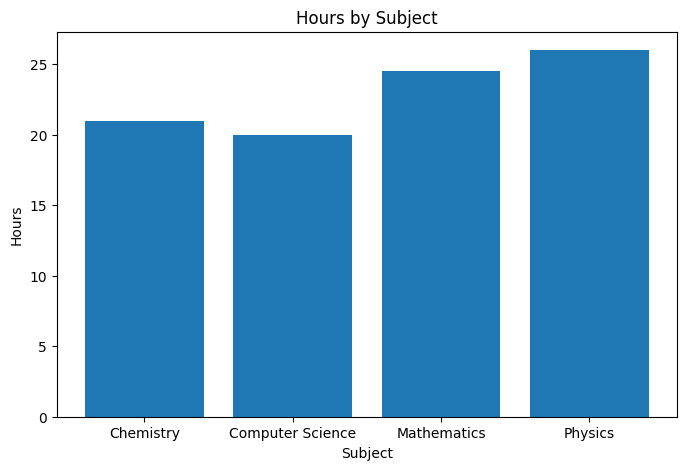

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(subject_hours.index, subject_hours.values)
plt.title('Hours by Subject')
plt.xlabel('Subject')
plt.ylabel('Hours')
plt.savefig('Hours_by_subject.png')
plt.show()


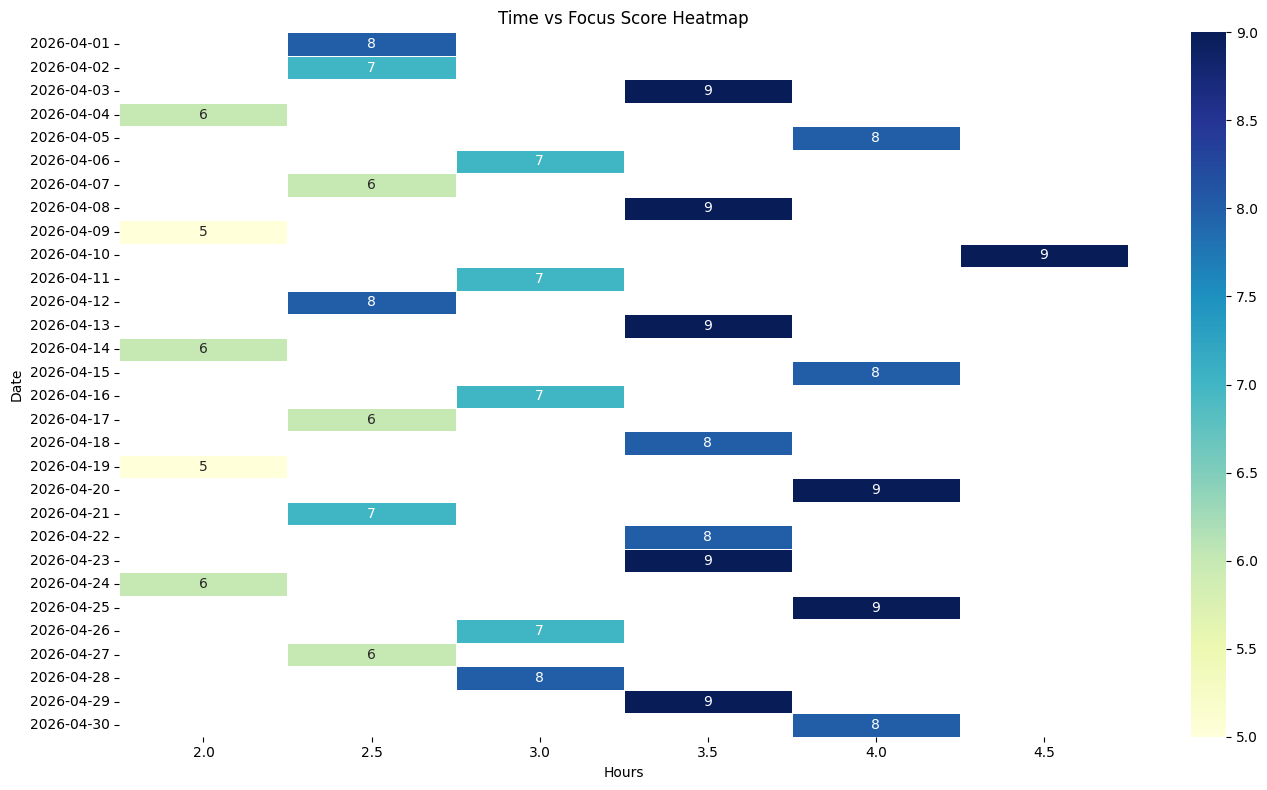

In [ ]:
heatmap_data = df.pivot_table(
    values='Focus_Score',
    index='Date',
    columns='Study_Hours',
    aggfunc='mean'
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Time vs Focus Score Heatmap')
plt.xlabel('Hours')
plt.ylabel('Date')

plt.tight_layout()

plt.savefig('Time_vs_Focus.png')

plt.show()

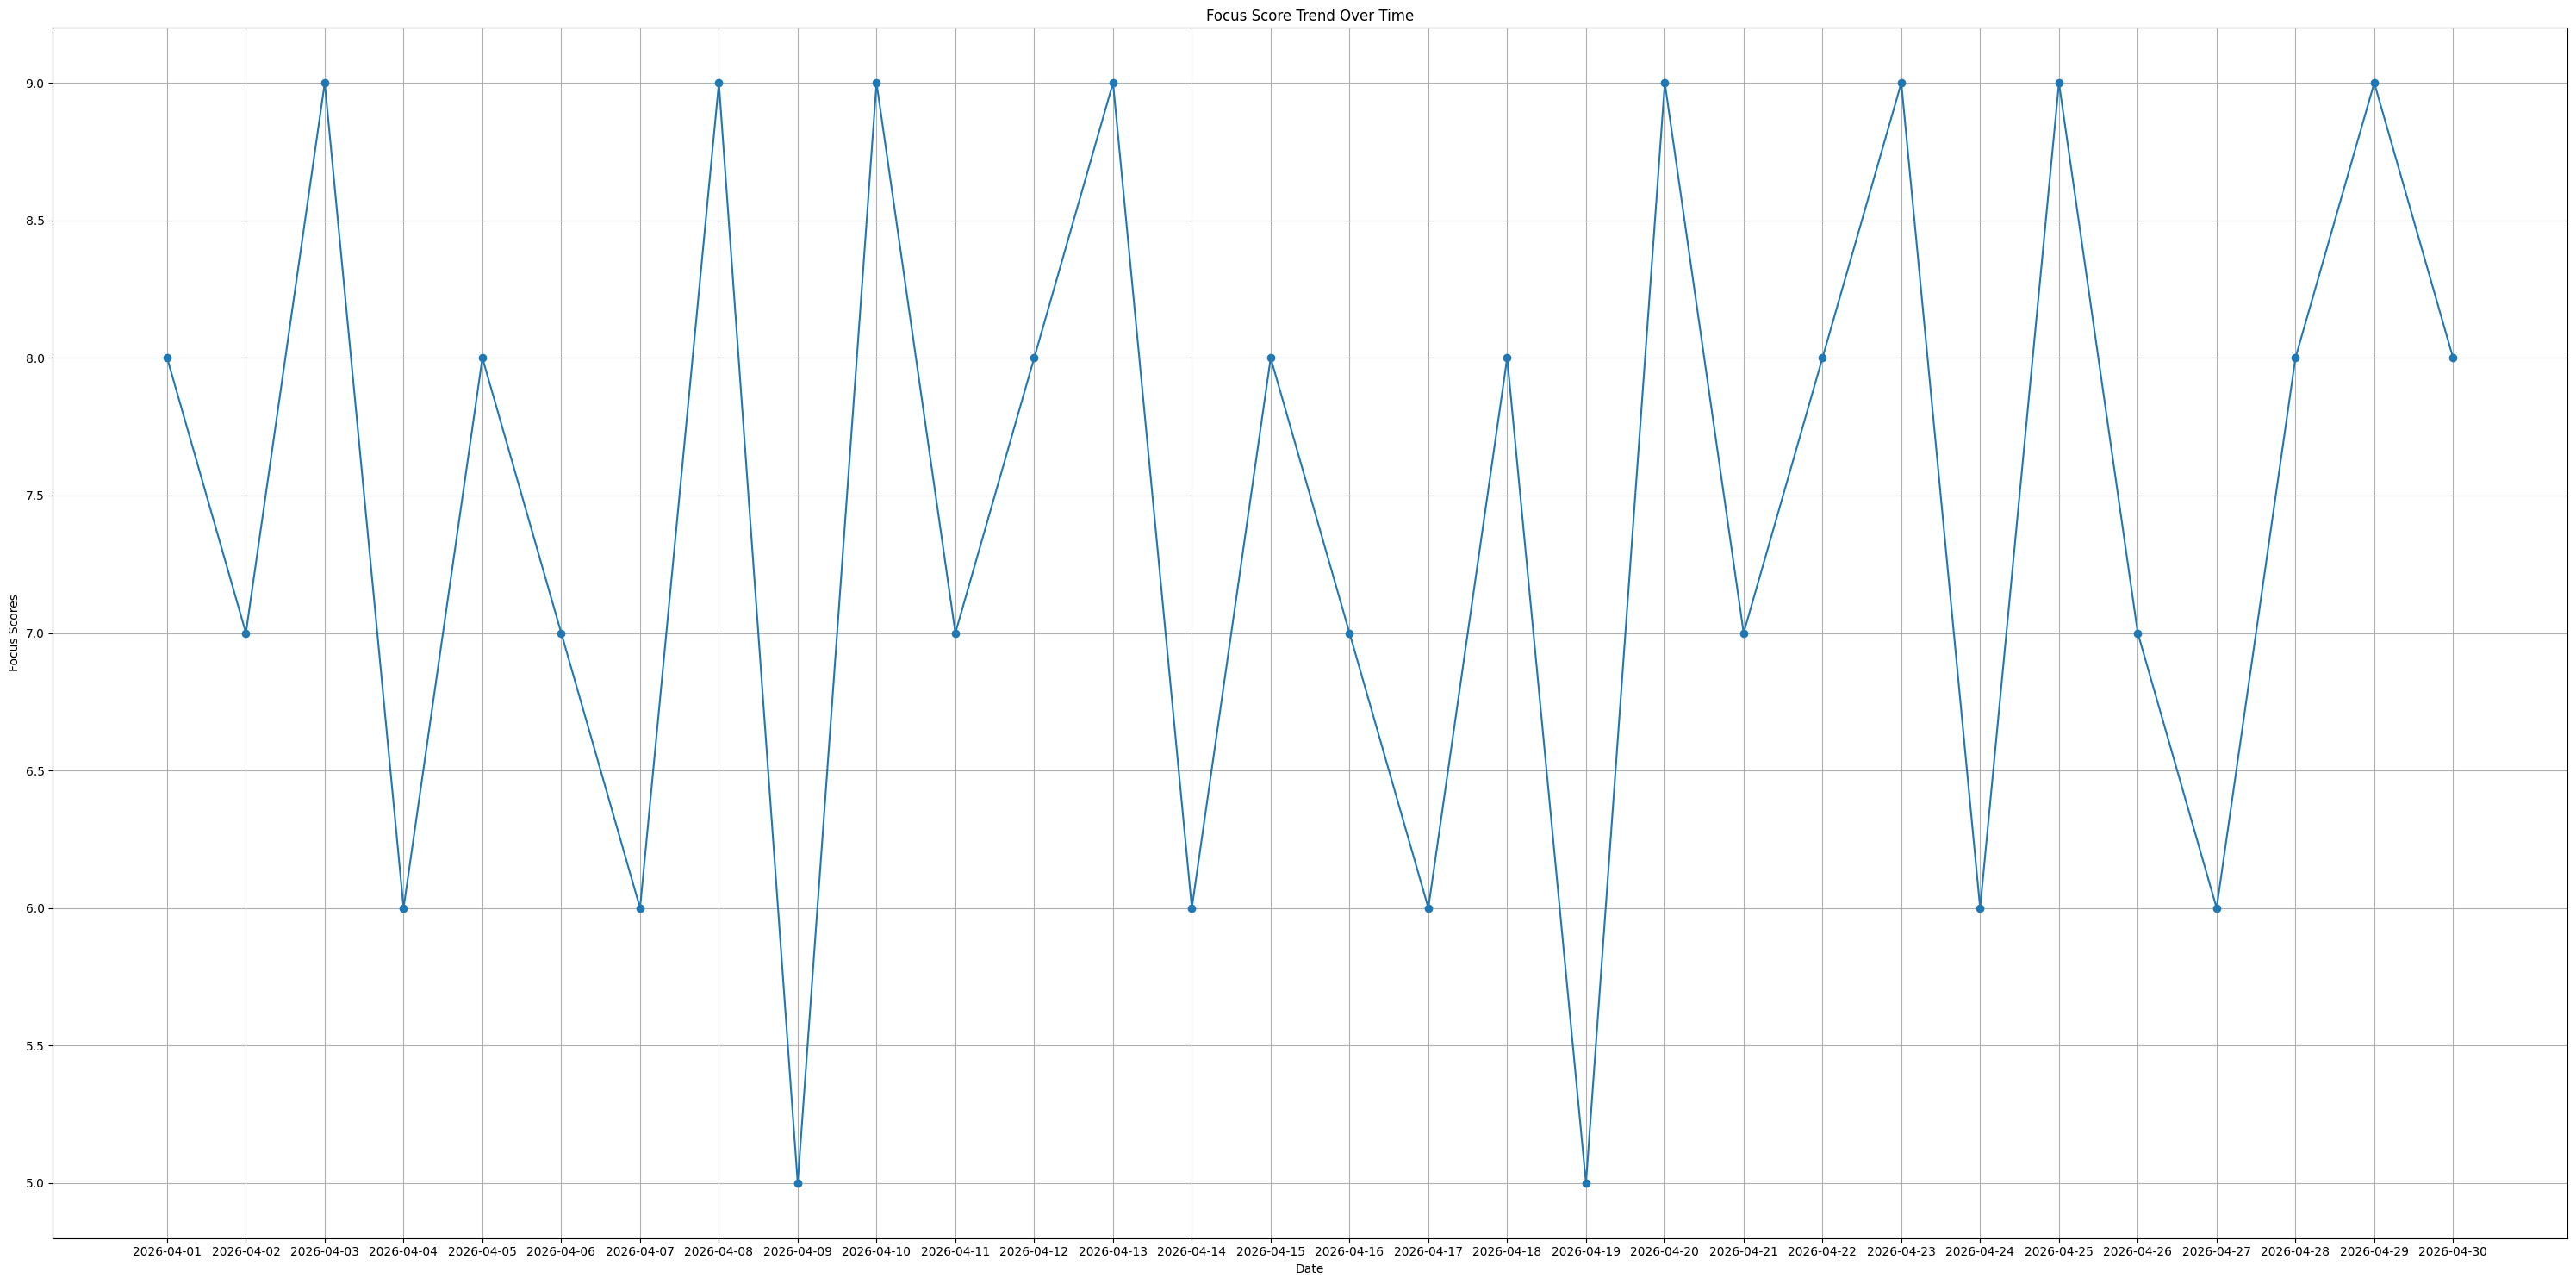

In [ ]:
plt.figure(figsize=(30, 15))
plt.plot(
    df['Date'],
    df['Focus_Score'],
    marker='o'
)

plt.title('Focus Score Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Focus Scores')
plt.grid(True)
plt.tight_layout()

plt.savefig('Focus_Trend.png')
plt.show()

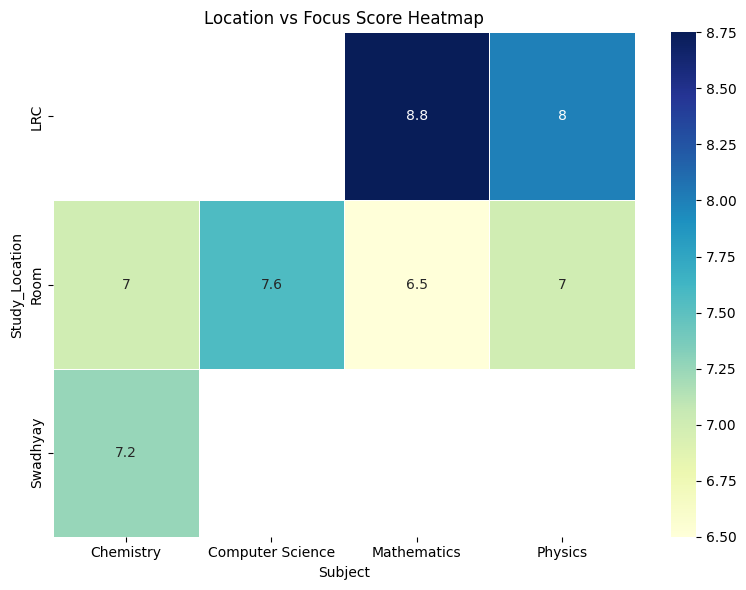

In [ ]:
heatmap_data = df.pivot_table(
    values='Focus_Score',
    index='Study_Location',
    columns='Subject',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Location vs Focus Score Heatmap')

plt.tight_layout()

plt.savefig('Location_vs_Focus_Heatmap.png')

plt.show()

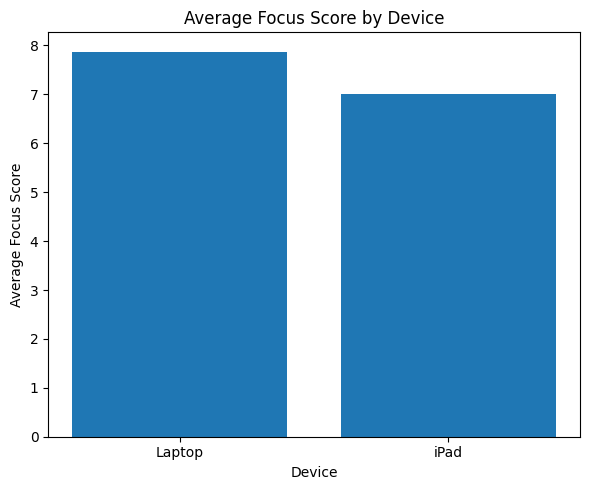

In [ ]:
device_focus = df.groupby('Device_Used')['Focus_Score'].mean()

plt.figure(figsize=(6,5))

plt.bar(device_focus.index, device_focus.values)

plt.title('Average Focus Score by Device')
plt.xlabel('Device')
plt.ylabel('Average Focus Score')

plt.tight_layout()

plt.savefig('Device_vs_Focus.png')

plt.show()

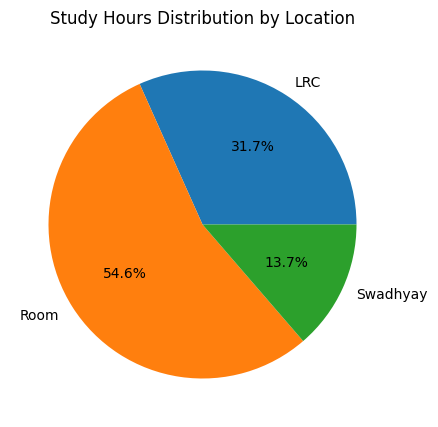

In [ ]:
location_hours = df.groupby('Study_Location')['Study_Hours'].sum()

plt.figure(figsize=(7,5))

plt.pie(
    location_hours.values,
    labels=location_hours.index,
    autopct='%1.1f%%'
)

plt.title('Study Hours Distribution by Location')

plt.savefig('Location_Distribution.png')

plt.show()
